All the X-ray analysis in one place. Light curves and Lx plot. Fitting the spectra. Is the G203 upper limit worth an XMM observation?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import astropy.io.fits as fits
import os
import glob
from astropy.table import Table
from astropy.io import ascii
from astropy.convolution import convolve, Box1DKernel, Gaussian1DKernel
import astropy.constants as const
import astropy.units as u
import importlib
from astropy.modeling import models, fitting
from astropy.time import Time


#matplotlib set up
%matplotlib inline
from matplotlib import rcParams
rcParams["figure.figsize"] = (14, 5)
rcParams["font.size"] = 20

In [2]:
swiftlc = Table.read('/media/david/2tb_ext_hd/hddata/carmenes_binary/gj207.1/swift/xrt/USERPROD_247053/lc/curve.qdp')
# swiftlc
xtime = swiftlc['col1']
xcounts = swiftlc['col2']
xcounts_e = np.array([swiftlc['col2_perr'], abs(swiftlc['col2_nerr'])])

<ErrorbarContainer object of 3 artists>

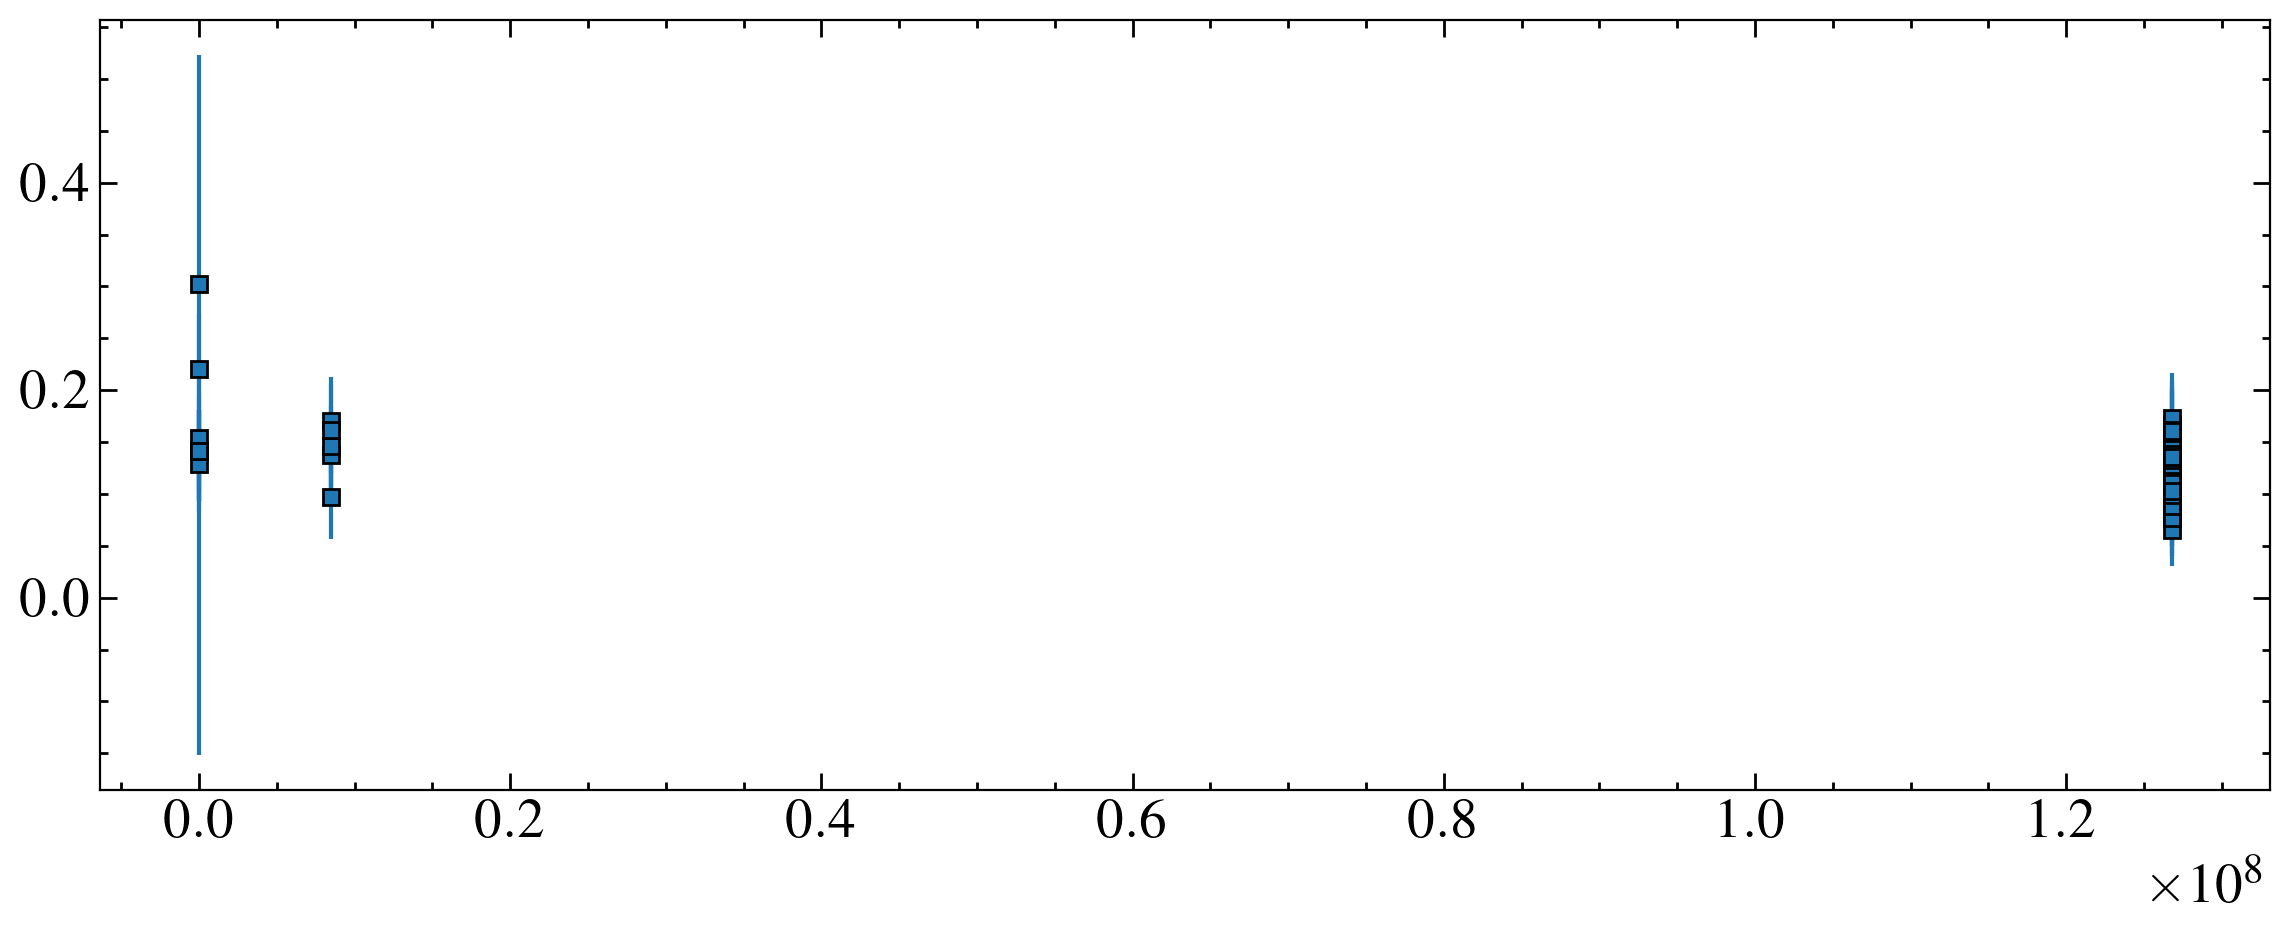

In [3]:
fig, ax = plt.subplots()

ax.errorbar(xtime, xcounts, yerr = xcounts_e, marker='s', ls='none', markeredgecolor='k', label=r'XRT')


In [4]:
swiftlc = Table.read('/media/david/2tb_ext_hd/hddata/carmenes_binary/wolf1130/swift/xrt/lc/USERPROD_251678/lc/curve.qdp')
# swiftlc
xtime = swiftlc['col1']
xcounts = swiftlc['col2']
xcounts_e = np.array([swiftlc['col2_perr'], abs(swiftlc['col2_nerr'])])

<ErrorbarContainer object of 3 artists>

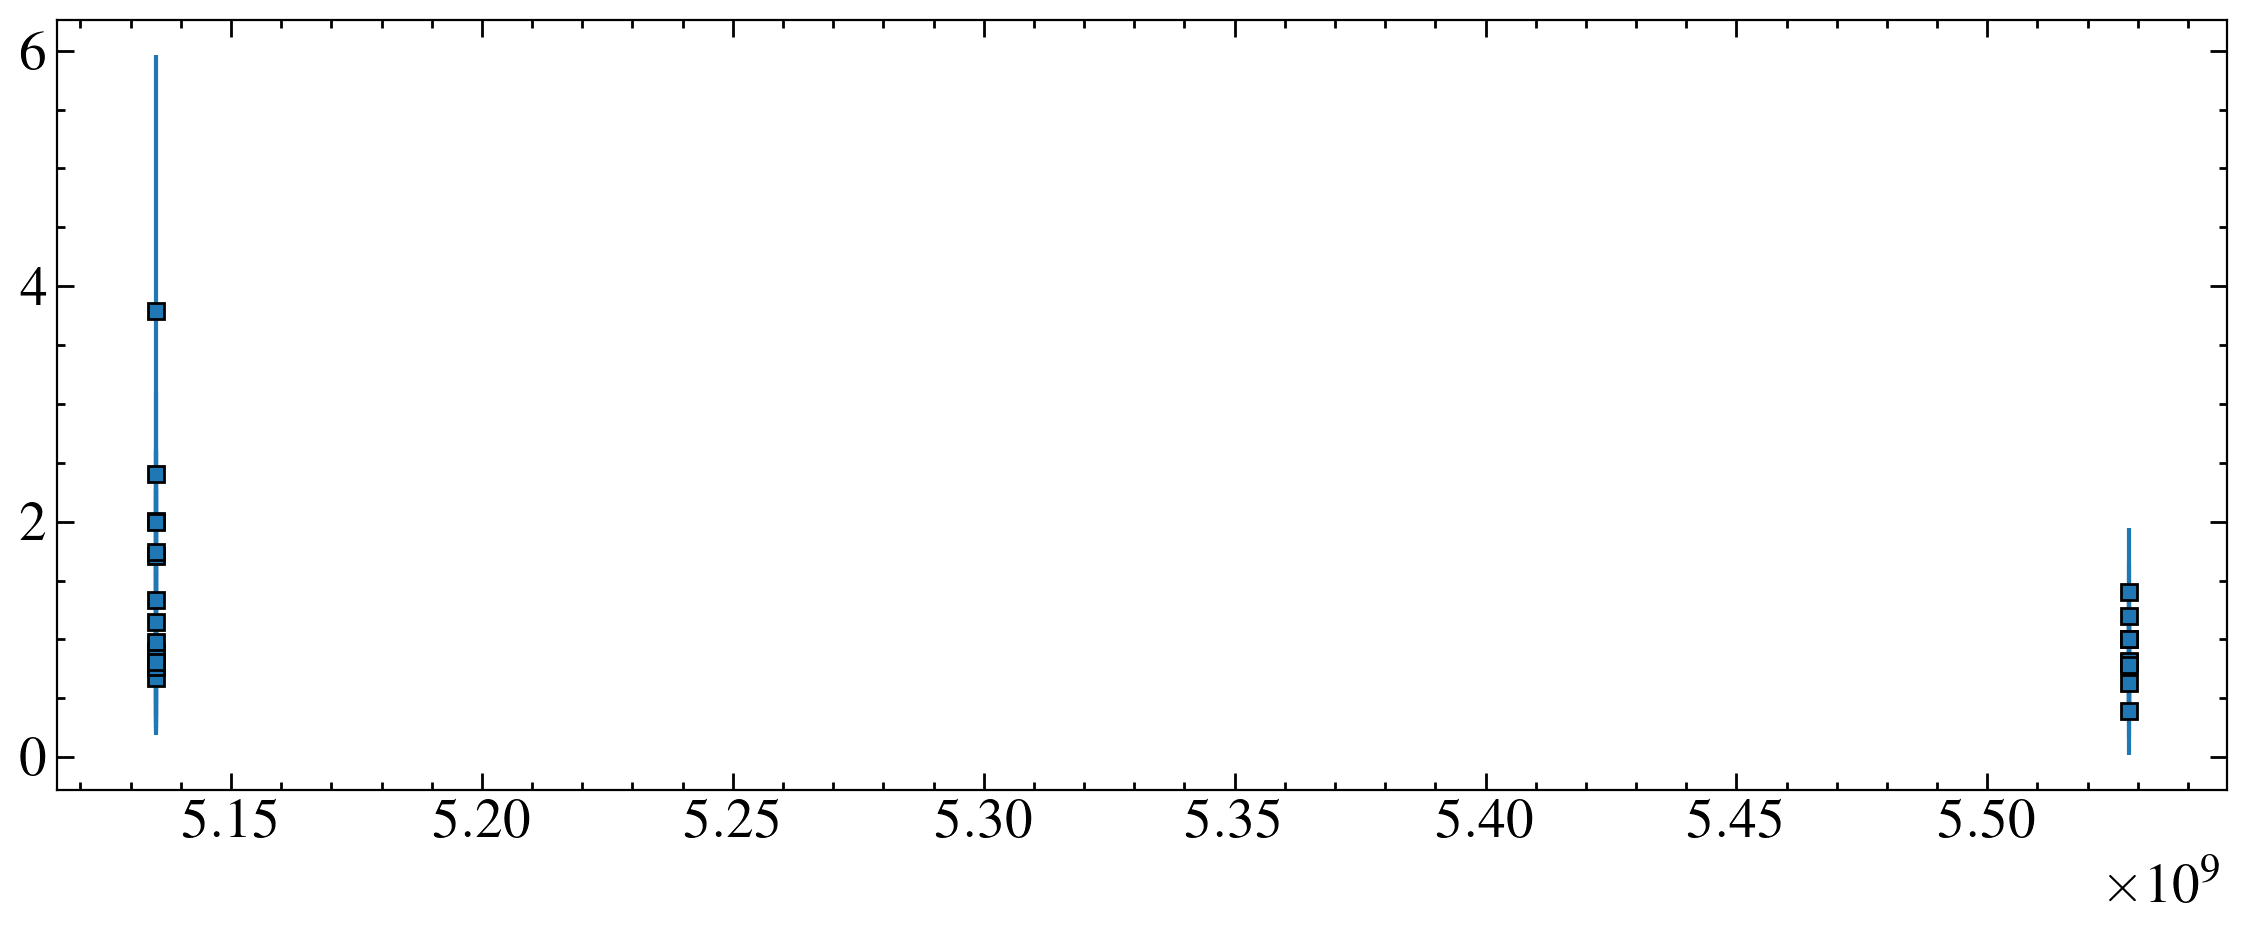

In [5]:
#swift reference times
ref_mjd = 51910
ref_sec = ref_mjd * 86400
xref = 650034242.0006 #different for X-ray

fig, ax = plt.subplots()
xmask = xtime > 0 #just this observation
xt = xtime[xmask] + xref + ref_sec
xf, xe = xcounts[xmask] / np.median(xcounts[xmask]), np.array([xcounts_e[0][xmask] / np.median(xcounts[xmask]), xcounts_e[1][xmask] / np.median(xcounts[xmask])])
ax.errorbar(xt, xf, yerr = xe, marker='s', ls='none', markeredgecolor='k', label=r'XRT')


In [6]:
swiftlc = Table.read('/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/swift/xrt/lightcurve/USERPROD_255053/lc/curve.qdp')
# swiftlc
xtime = swiftlc['col1']
xcounts = swiftlc['col2']
xcounts_e = np.array([swiftlc['col2_perr'], abs(swiftlc['col2_nerr'])])

<ErrorbarContainer object of 3 artists>

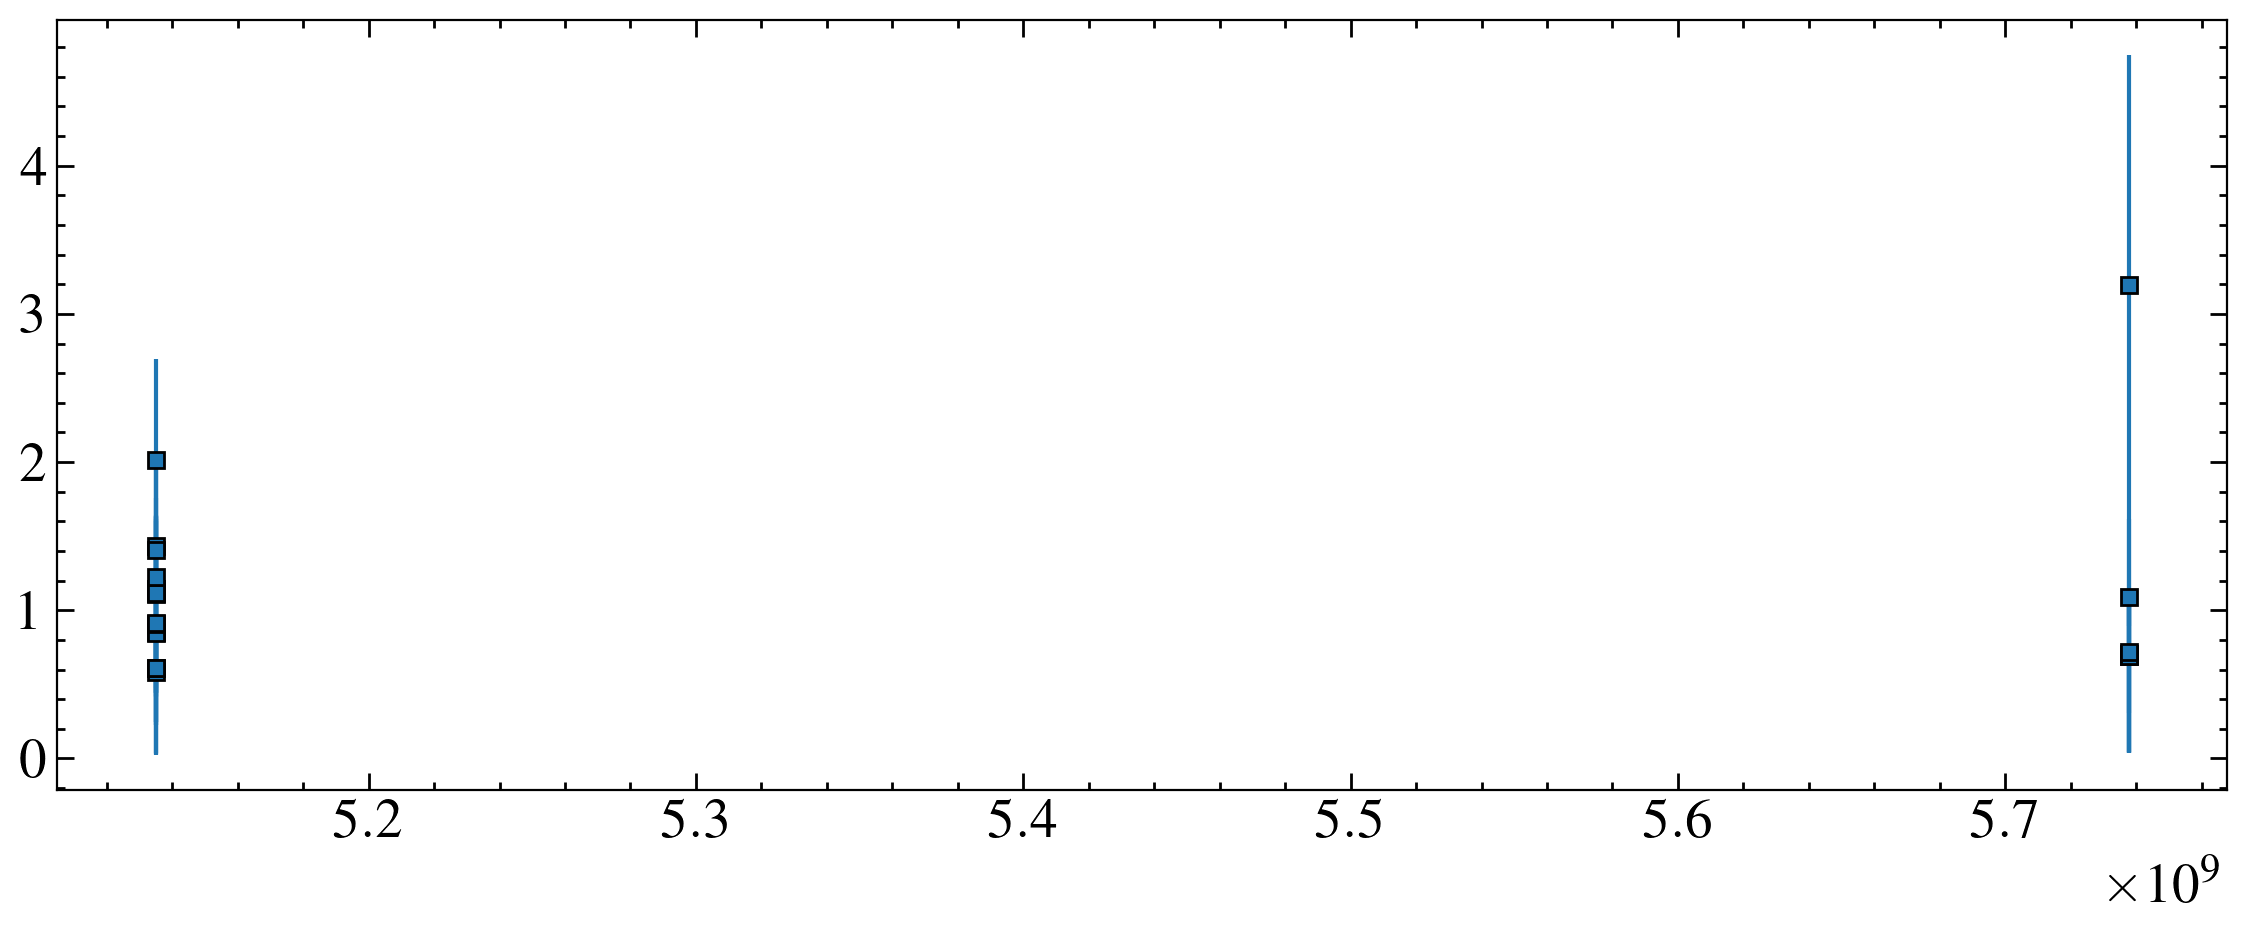

In [7]:
#swift reference times
ref_mjd = 51910
ref_sec = ref_mjd * 86400
xref = 650034242.0006 #different for X-ray

fig, ax = plt.subplots()
xmask = xtime > 0 #just this observation
xt = xtime[xmask] + xref + ref_sec
xf, xe = xcounts[xmask] / np.median(xcounts[xmask]), np.array([xcounts_e[0][xmask] / np.median(xcounts[xmask]), xcounts_e[1][xmask] / np.median(xcounts[xmask])])
ax.errorbar(xt, xf, yerr = xe, marker='s', ls='none', markeredgecolor='k', label=r'XRT')


472396054.7055998 1075052654.7055998


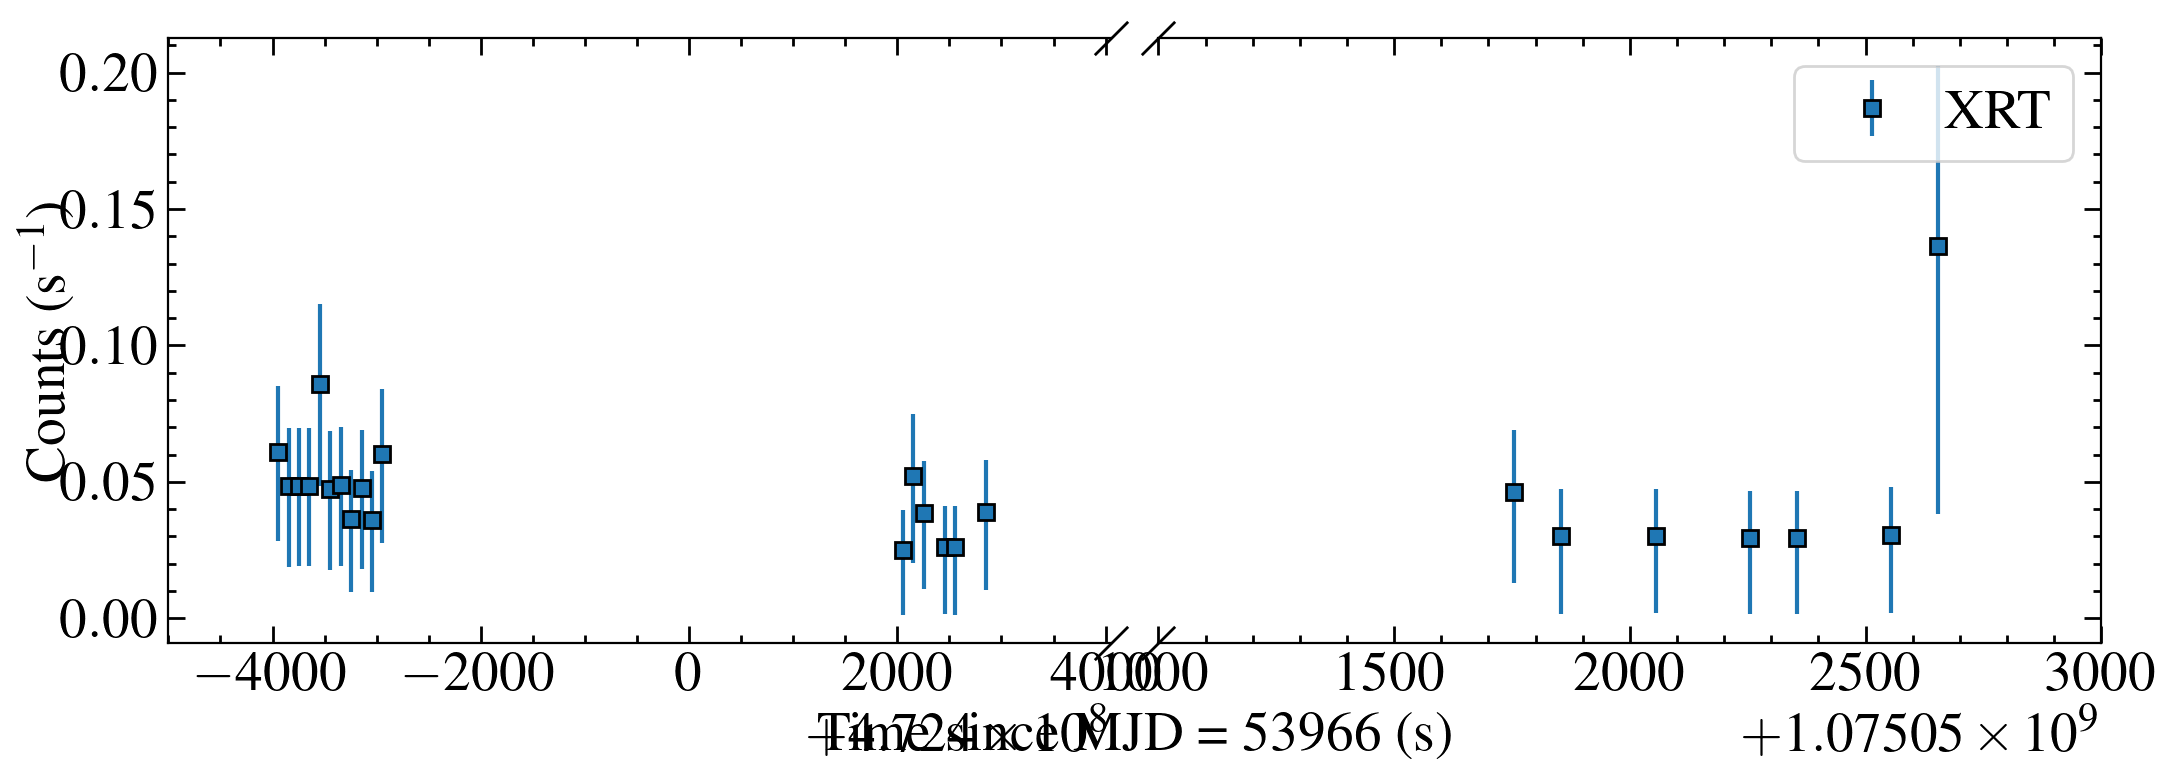

In [23]:
fig, axes = plt.subplots(ncols=2, sharey = True, figsize=(12, 5)) 

#swift reference times
ref_mjd = 51910
ref_sec = ref_mjd * 86400

xref = 650034242.0006 #different for X-ray

mjd0 = 53966 #day of first XRT observation

# for i,  lc in enumerate(lcs[::-1][1]):
for j in range(len(axes)):

   
    #xrt
    # xmask = xtime > 0 #just this observation
    xt = xtime + xref + ref_sec- mjd0 *86400
    xf, xe = xcounts, np.array([xcounts_e[0], xcounts_e[1] ]) 
    axes[j].errorbar(xt, xf, yerr = xe, marker='s', ls='none', markeredgecolor='k', label=r'XRT')
    
print(xt[0], xt[-1])    

# axes[0].set_ylim(0.31, 1.99) # should only need to set the ylims on the first subplot because sharey = True
axes[0].set_xlim(472395000, 472404054) #setting up the ranges that the plots will cover. One row per subplot
axes[1].set_xlim(1075051000, 1075053000)

# axes[0].legend(frameon=True, loc=3)
axes[1].legend(frameon=True, loc=1)

"""
Everything between here and the next docstring should work regardless of how many subplots you have
"""

#setting up the slanted lines
d = 1.  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)

for i in range(len(axes)):
    
    # axes[i].scatter(xs, ys, edgecolor='k') #add the points to each plot
    
    if i > 0: #turn off yticks for everything except the first plot
        axes[i].yaxis.set_tick_params(labelleft=False)
      
    if i != len(axes)-1: #do these things for every subplot exept the last
        axes[i].spines.right.set_visible(False) #turn off right ax
        axes[i].tick_params(right = False, which='both') #turn off right ticks
        axes[i].plot([1, 1], [0, 1], transform=axes[i].transAxes, **kwargs) #add the slanted line to the right corners
   
    if i > 0: #do these things for every subplot except the first
        axes[i].spines.left.set_visible(False) #as for the last loop but for the left
        axes[i].tick_params(left = False, which='both')
        axes[i].plot([0, 0], [1, 0], transform=axes[i].transAxes, **kwargs)
        
"""
Just the axes labels beyond this.
"""    
#add a frame that goes around all the subplots to add the labels       
bigax = fig.add_subplot(111, frame_on=False)
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False, which='both')
bigax.set_ylabel('Counts (s$^{-1}$)') #change labelpad if the label is overlapping the tick labels
bigax.set_xlabel('Time since MJD = {} (s)'.format(mjd0))
# bigax.set_title('Example plot with split x axis', pad =15) 

fig.tight_layout()
fig.subplots_adjust(wspace=0.05) #change the gap in between the subplots

# fig.savefig('plots/g207d1_swift_lcs.pdf')


In [24]:
# swiftlc

Ok so for both the detections we can use the last spectrum. For Wolf 1130 use spectrum number 2. Will fit them in xspec rather than mess around with pyxspec. Nope, pyxspec Estimate nh from Allison's paper? Fix at 18

GJ 207.1  
<!-- 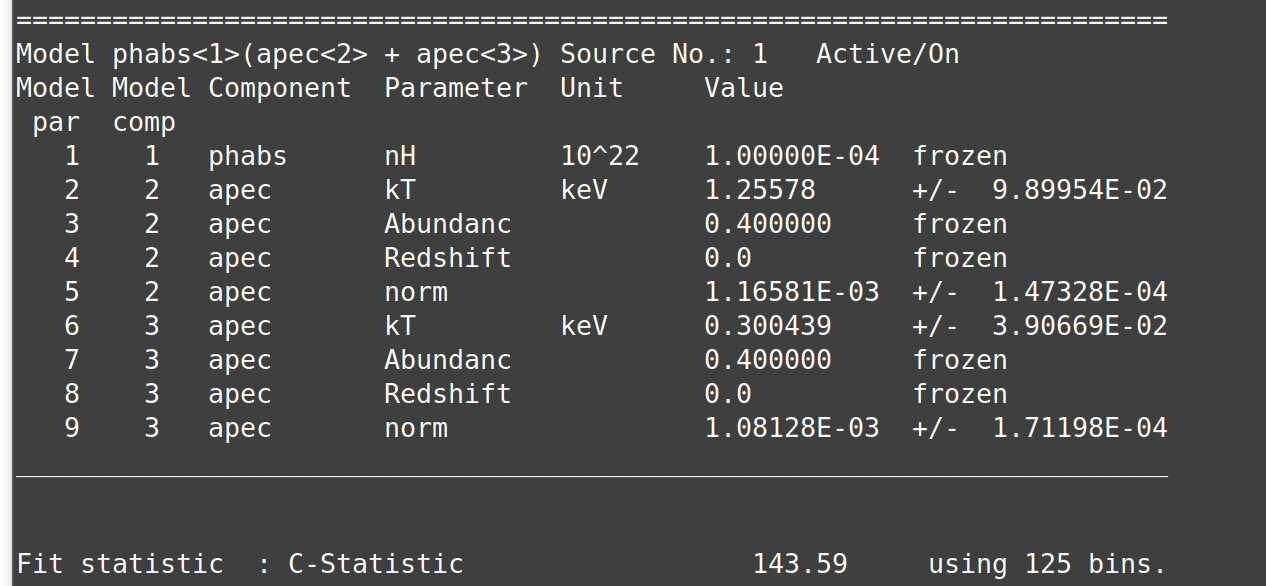 -->

In [6]:
from xspec import *
Plot.device = '/null'


In [4]:
path = '/media/david/2tb_ext_hd/hddata/carmenes_binary/'
stars = ['gj207.1', 'lhs1817', 'wolf1130']
obs = [3, 2, 2]
# for star, ob in zip(stars, obs):
    # print(os.listdir('{}{}/swift/xrt/spectra/obs{}'.format(path, star, ob)))
for i, star in enumerate(stars):
    starpath = '{}{}/swift/xrt/spectra/obs{}/'.format(path, star, obs[i])
    # print(starpath)

obsname = ['interval0', 'Obs_00036027002', 'Obs_00040011003']

/media/david/2tb_ext_hd/hddata/carmenes_binary/gj207.1/swift/xrt/spectra/obs3/
/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/swift/xrt/spectra/obs2/
/media/david/2tb_ext_hd/hddata/carmenes_binary/wolf1130/swift/xrt/spectra/obs2/


gj207.1
***Warning: Detected response matrix energy bin value = 0 (or neg).
     XSPEC will instead use small finite value (response file will not be altered).

1 spectrum  in use
 
Spectral Data File: interval0pc.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  9.327e-02 +/- 5.710e-03 (98.7 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-254
  Telescope: SWIFT Instrument: XRT  Channel Type: PI
  Exposure Time: 2899 sec
 Using fit statistic: cstat
 Using Background File                interval0pcback.pi
  Background Exposure Time: 2899 sec
 Using Response (RMF) File            interval0pc.rmf for Source 1
 Using Auxiliary Response (ARF) File  interval0pc.arf


Fit statistic  : C-Statistic                  455.08     using 254 bins.

Test statistic : Chi-Squared                  175.34     using 254 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 1.00e+00 

ValueError: x and y must have same first dimension, but have shapes (125,) and (29,)

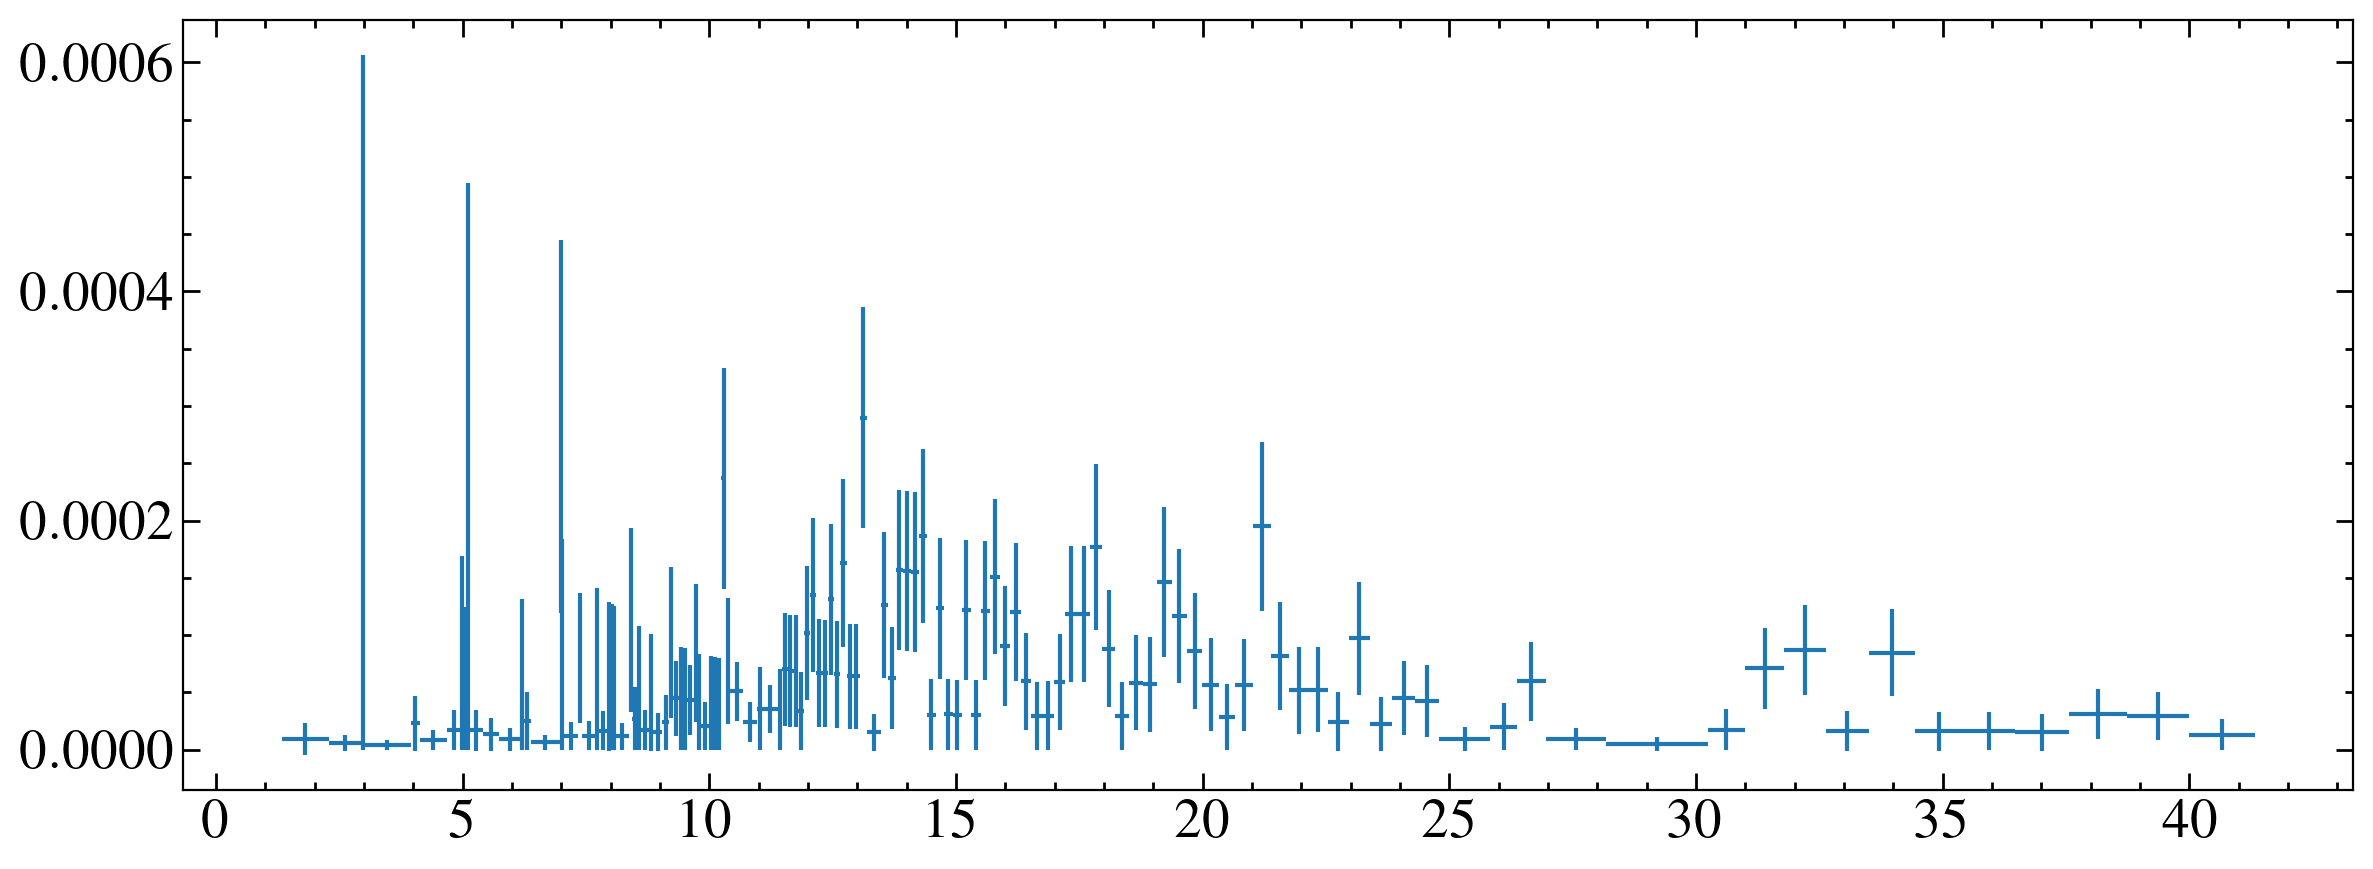

In [15]:
napec = [1, 1, 1]
fluxes = []
fluxes_eu = []
fluxes_el = []


for i, star in enumerate(stars):
    print(star)

    fig, ax = plt.subplots()
    # ax.set_xscale('log')
    
    # s = Spectrum('{}_src_spectrum_bin{}.ds'.format(star, specbins[i]), backFile='{}_bkg_spectrum_grp.ds'.format(star), respFile='{}_response_grp.rmf'.format(star))#, arfFile='{}_EMOS1.arf'.format(star))
    # starpath = '{}{}/swift/xrt/spectra/obs{}/'.format(path, star, obs[i])
    # src = glob.glob('{}*pc.pi'.format(starpath))[0]
    # bk = glob.glob('{}*pcback.pi'.format(starpath))[0]
    # rmf = glob.glob('{}*pc.rmf'.format(starpath))[0]
    # arf = glob.glob('{}*pc.arf'.format(starpath))[0]
    # print(src, bk, rmf, arf)
    src = '{}pc.pi'.format(obsname[i])
    # s = Spectrum(src, backFile=bk, respFile=rmf, arfFile=arf)
    s = Spectrum(src)
     
    
    Plot('data')
    Plot.xAxis='angstrom'
    # s.ignore('**-5.0 50.0-**')
    # s.ignore('bad')
    AllData.ignore("bad")

     
    Plot.perHz=False
    Plot.area=True
    Plot('data')
    Plot.setRebin(3,5, 1)

    wave = Plot.x()
    rates = Plot.y()
    bins = Plot.xErr()
    error = Plot.yErr()
    

        
    
    ax.errorbar(wave, rates, xerr=bins, yerr=error, ls='none')
    AllModels.setEnergies("0.1 2.4")


    # plt.errorbar(wave, rates)
    if napec[i] == 1:
        mod = Model('apec*phabs', setPars={1:1, 2:0.4, 5:1e-4})
        mod.phabs.nH.frozen = True
        Fit.statMethod = 'cstat'
        Fit.renorm()
        Fit.perform()
        Plot('data')
        folded = Plot.model()
        ax.plot(wave, folded)

    
    else:
    
        mod2 = Model('phabs*(apec+apec)', setPars={1:1e-4, 2:1,3:0.4,6:0.5, 7:0.4})
        mod2.phabs.nH.frozen = True
        Fit.renorm()
        Fit.perform()
        Plot('data')
        folded = Plot.model()
        plt.plot(wave, folded)

          
    flux = AllModels.calcFlux("0.1 2.4 err")
    print(flux)
    plt.show()
    # s.flux[0]*u.erg/u.cm**2/u.s, (s.flux[0]-s.flux[1])*u.erg/u.cm**2/u.s, (s.flux[2]-s.flux[0])*u.erg/u.cm**2/u.s  
    
    fluxes.append(s.flux[0])
    fluxes_eu.append(s.flux[2]-s.flux[0])
    fluxes_el.append(s.flux[0]-s.flux[1])
    
    
    DataManager.clear(s)
    
# print(napec)   


In [37]:
# Spectrum(src)

New filename ( "none" or "/*" to return to the XSPEC prompt): No such file: .rsp
New filename ( "none" or "/*" to return to the XSPEC prompt): No such file: .rsp
New filename ( "none" or "/*" to return to the XSPEC prompt): No such file: .rsp



Error: cannot read response file interval0pc.rmf
terminated at user request


ValueError: PyCapsule_New called with null pointer

urgh it has to be done in this dir